# EDA

In [45]:
import nltk
nltk.download('omw-1.4')
import warnings
warnings.filterwarnings("ignore")  
import collections
import folium
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.collocations import (
    BigramAssocMeasures,
    BigramCollocationFinder)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import random
import re
import string 
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ashke\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashke\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Import data

In [7]:
DATASET = "./data/train.csv"
df = pd.read_csv(DATASET)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28122 entries, 0 to 28121
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      28122 non-null  int64  
 1   month                   28122 non-null  object 
 2   name                    28092 non-null  object 
 3   description             27833 non-null  object 
 4   transit                 19212 non-null  object 
 5   host_since              28120 non-null  object 
 6   host_response_rate      23067 non-null  object 
 7   host_has_profile_pic    28120 non-null  object 
 8   host_identity_verified  28120 non-null  object 
 9   neighbourhood           27861 non-null  object 
 10  city                    28113 non-null  object 
 11  zipcode                 27204 non-null  object 
 12  latitude                28122 non-null  float64
 13  longitude               28122 non-null  float64
 14  property_type           28122 non-null

In [8]:
df.head()

,id,month,name,description,transit,host_since,host_response_rate,host_has_profile_pic,host_identity_verified,neighbourhood,...,amenities,price,minimum_nights,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,instant_bookable,cancellation_policy
0,10595,February,"96m2, 3BR, 2BA, Metro, WI-FI etc...",Athens Furnished Apartment No6 is 3-bedroom ap...,Note: 5-day ticket for all the public transpor...,2009-09-08,100%,t,t,Ambelokipi,...,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",$71.00,1,294,17,2011-05-20,2019-01-12,96.0,t,strict_14_with_grace_period
1,10988,February,"75m2, 2-br, metro, wi-fi, cable TV",Athens Furnished Apartment No4 is 2-bedroom ap...,Note: 5-day ticket for all the public transpor...,2009-09-08,100%,t,t,Ambelokipi,...,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",$82.00,1,0,31,2012-10-21,2017-11-23,92.0,t,strict_14_with_grace_period
2,10990,February,"50m2, Metro, WI-FI, cableTV, more",Athens Furnished Apartment No3 is 1-bedroom ap...,Note: 5-day ticket for all the public transpor...,2009-09-08,100%,t,t,Ambelokipi,...,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",$47.00,1,282,27,2012-09-06,2019-02-01,97.0,t,strict_14_with_grace_period
3,10993,February,"Studio, metro, cable tv, wi-fi, etc",The Studio is an -excellent located -close t...,Note: 5-day ticket for all the public transpor...,2009-09-08,100%,t,t,Ambelokipi,...,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",$37.00,1,286,42,2012-09-24,2019-02-02,97.0,t,strict_14_with_grace_period
4,10995,February,"47m2, close to metro,cable TV,wi-fi",AQA No2 is 1-bedroom apartment (47m2) -excell...,Note: 5-day ticket for all the public transpor...,2009-09-08,100%,t,t,Ambelokipi,...,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",$47.00,2,308,16,2010-07-08,2019-01-11,95.0,t,strict_14_with_grace_period


### Most commonly requested rooms

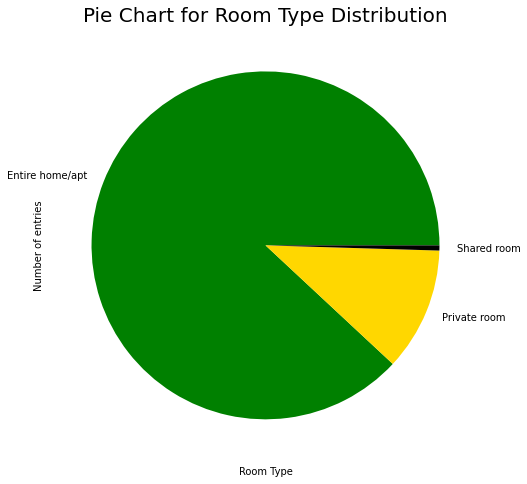

In [9]:
df['room_type'].value_counts().plot(kind = 'pie', colors=['green', 'gold', 'black'], figsize = (8, 8))
plt.title('Pie Chart for Room Type Distribution', fontsize = 20)
plt.xlabel('Room Type')
plt.ylabel('Number of entries')
plt.show()

Most common type of rooms is 'Entire home/apartment'

In [10]:
print('Number of entries for "Entire home/apartment": {}'.format(max(df['room_type'].value_counts())))

Number of entries for "Entire home/apartment": 24765


### Fluctuation of rent

In [11]:
def remove_dollar(row):
    if row[0] == '$':
        return row[1:]
    return row

df['price'] = df['price'].apply(lambda row: float(remove_dollar(row).replace(',','')))

In [12]:
mean_prices = []
months = ['February', 'March', 'April']
for month in months:
    mean_prices.append(np.mean(df.loc[df['month'] == month]['price']))

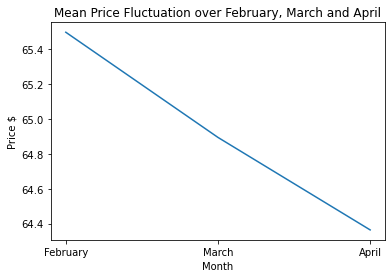

In [13]:
plot = plt.plot(months, mean_prices)
plt.xlabel('Month')
plt.ylabel('Price $')
plt.title('Mean Price Fluctuation over February, March and April')
plt.show()

In [14]:
for i, month in enumerate(months):
    print("Mean price in month {}: ${:.2f}".format(month, mean_prices[i]))

Mean price in month February: $65.50
Mean price in month March: $64.89
Mean price in month April: $64.36


### Areas with best experience 

Text(0.5, 1.0, 'Distribution of reviews in the top neighbourhoods')

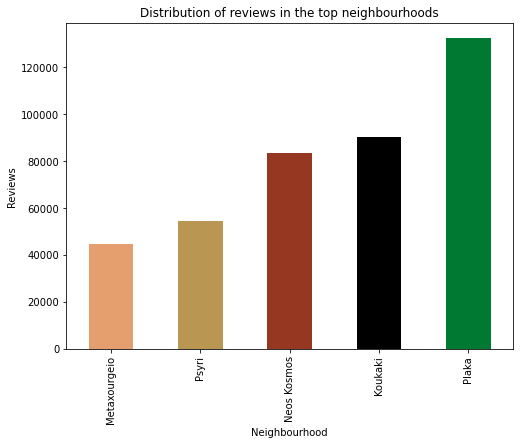

In [15]:
neighs = df.groupby('neighbourhood')
reviews = neighs['number_of_reviews'].sum().sort_values().tail(5)

reviews.plot(kind = 'bar', color=['#e59e6d', '#ba9653', '#963821', 'black', '#007a33'], figsize = (8, 6))
plt.xlabel('Neighbourhood')
plt.ylabel('Reviews')
plt.title('Distribution of reviews in the top neighbourhoods')

In [16]:
list_of_neighs = reviews.keys().tolist()
n_reviews = reviews.tolist()
print("Top 5 neighbourhoods are: \n")
for i,n in enumerate(list_of_neighs):
    print('{} with {} reviews'.format(n, n_reviews[i]))

Top 5 neighbourhoods are: 

Metaxourgeio with 44792 reviews
Psyri with 54353 reviews
Neos Kosmos with 83348 reviews
Koukaki with 90357 reviews
Plaka with 132361 reviews


### Largest area

In [17]:
res = df['neighbourhood'].value_counts()
neig = res.keys().tolist()[0]
n_props = res.tolist()[0]
print("The neighbourhood with the most listings is {} with {} properties".format(neig, n_props))

The neighbourhood with the most listings is Plaka with 3143 properties


### Available rooms for each area

In [18]:
neighbourhoods = df['neighbourhood'].value_counts().keys().tolist()
months = df['month'].value_counts().keys().tolist()

for neighbourhood in neighbourhoods:
    for month in reversed(months):
        print("{} in {}: {}".format(neighbourhood, month, 
            df.loc[(df['neighbourhood'] == neighbourhood) & (df['month'] == month)]['month'].value_counts().tolist()[0]))
    print("----------------------------")

Plaka in February: 990
Plaka in March: 1037
Plaka in April: 1116
----------------------------
Neos Kosmos in February: 777
Neos Kosmos in March: 791
Neos Kosmos in April: 809
----------------------------
Koukaki in February: 741
Koukaki in March: 771
Koukaki in April: 806
----------------------------
Kolonaki in February: 525
Kolonaki in March: 586
Kolonaki in April: 611
----------------------------
Pangrati in February: 522
Pangrati in March: 578
Pangrati in April: 602
----------------------------
Larissis in February: 472
Larissis in March: 548
Larissis in April: 557
----------------------------
Metaxourgeio in February: 481
Metaxourgeio in March: 521
Metaxourgeio in April: 525
----------------------------
Ambelokipi in February: 469
Ambelokipi in March: 502
Ambelokipi in April: 511
----------------------------
Psyri in February: 483
Psyri in March: 485
Psyri in April: 504
----------------------------
Exarcheia in February: 382
Exarcheia in March: 468
Exarcheia in April: 480
--------

Below we are plotting for three randomly selected neighbourhoods the listings for each month

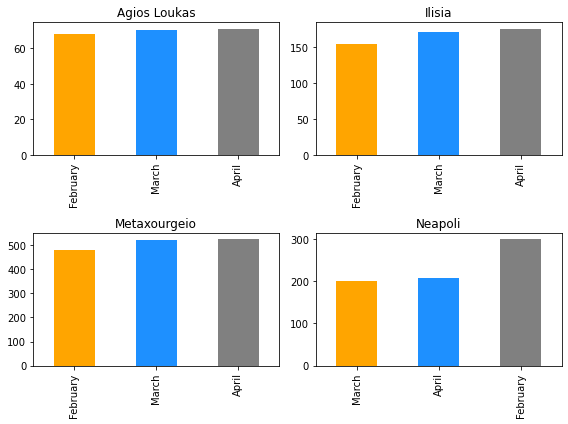

In [19]:
rand_neighbourhoods = random.choices(neighbourhoods, k=4)

fig = plt.figure()

for idx, rand_neighbourhood in enumerate(rand_neighbourhoods):
    ax = fig.add_subplot(2, 2, idx+1)
    df.loc[df['neighbourhood'] == rand_neighbourhood]['month'].value_counts().sort_values().plot(kind = 'bar', color = ['orange', 'dodgerblue', 'gray'], figsize = (8, 6))
    ax.set_title(rand_neighbourhood)

plt.tight_layout()
plt.show()

### Area frequencies

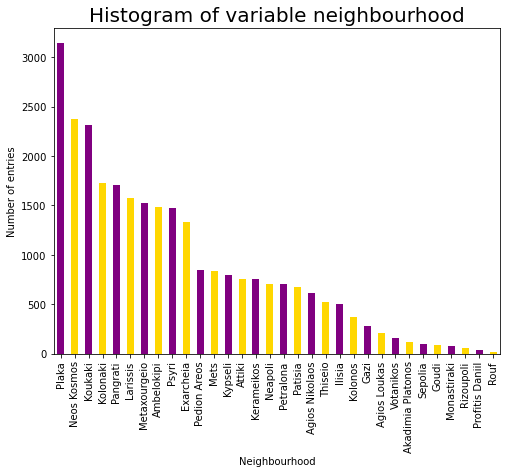

In [20]:
df['neighbourhood'].value_counts().plot(kind = 'bar', color = ['purple','gold'], figsize = (8, 6))
plt.title('Histogram of variable neighbourhood', fontsize = 20)
plt.xlabel('Neighbourhood')
plt.ylabel('Number of entries')
plt.show()

### Most requested room type

In [21]:
print("Most common type of room in every neighbourhood: \n")
for neighbourhood in neighbourhoods:
    print("{}: {} - entries: {}".format(neighbourhood, 
                                    np.argmax(df.loc[df['neighbourhood'] == neighbourhood]['room_type'].value_counts()),
                                    np.max(df.loc[df['neighbourhood'] == neighbourhood]['room_type'].value_counts())))


Most common type of room in every neighbourhood: 

Plaka: 0 - entries: 2869
Neos Kosmos: 0 - entries: 2177
Koukaki: 0 - entries: 2104
Kolonaki: 0 - entries: 1615
Pangrati: 0 - entries: 1557
Larissis: 0 - entries: 1276
Metaxourgeio: 0 - entries: 1157
Ambelokipi: 0 - entries: 1386
Psyri: 0 - entries: 1182
Exarcheia: 0 - entries: 1171
Pedion Areos: 0 - entries: 679
Mets: 0 - entries: 782
Kypseli: 0 - entries: 645
Attiki: 0 - entries: 647
Kerameikos: 0 - entries: 682
Neapoli: 0 - entries: 608
Petralona: 0 - entries: 637
Patisia: 0 - entries: 620
Agios Nikolaos: 0 - entries: 524
Thiseio: 0 - entries: 478
Ilisia: 0 - entries: 473
Kolonos: 0 - entries: 321
Gazi: 0 - entries: 240
Agios Loukas: 0 - entries: 177
Votanikos: 0 - entries: 146
Akadimia Platonos: 0 - entries: 92
Sepolia: 0 - entries: 89
Goudi: 0 - entries: 63
Monastiraki: 0 - entries: 58
Rizoupoli: 0 - entries: 40
Profitis Daniil: 0 - entries: 38
Rouf: 0 - entries: 12


### Costliest room

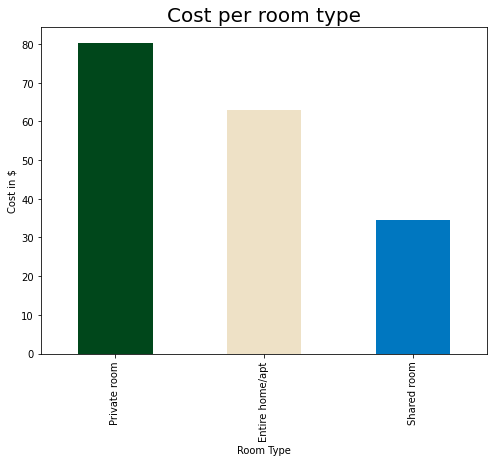

In [22]:
room_types = df.groupby('room_type')
prices = room_types['price'].mean().sort_values(ascending = False)
prices.plot(kind = 'bar', color=['#00471b', '#eee1c6', '#0077c0'] ,figsize = (8, 6))
plt.title('Cost per room type', fontsize = 20)
plt.xlabel('Room Type')
plt.ylabel('Cost in $')
plt.show()

In [23]:
types = prices.keys().tolist()
values = prices.tolist()

print('The most expensive room type is "{}" with {:.1f} mean price'.format(types[0], values[0]))

The most expensive room type is "Private room" with 80.3 mean price


### Locations of some rooms

In [24]:
data = df[['latitude', 'longitude', 'transit']].loc[df['month'] == 'February']
data.dropna(inplace=True)
tooltip = 'Click me!'

for row in data.itertuples():
    mapit = folium.Map(location=[row.latitude, row.longitude], zoom_start=12)

for row in data[:100].itertuples():
    folium.Marker(location=[row.latitude, row.longitude], popup=row.transit, icon=folium.Icon(icon='info-sign')).add_to(mapit)

In [25]:
mapit

### Top rated areas

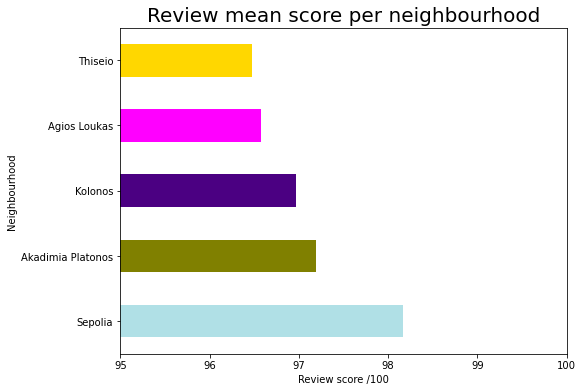

In [31]:
scores = neighs['review_scores_rating'].mean().sort_values(ascending = False).head(5)
scores.plot(kind = 'barh', color=['powderblue', 'olive', 'indigo', 'magenta', 'gold'] ,figsize = (8, 6))
plt.title('Review mean score per neighbourhood', fontsize = 20)
plt.xlim((95,100))
plt.ylabel('Neighbourhood')
plt.xlabel('Review score /100')
plt.show()

In [32]:
list_of_neighs = scores.keys().tolist()
n_scores = scores.tolist()
# And print its members
print("Top 5 neighbourhoods are: \n")
for i,n in enumerate(list_of_neighs):
    print('{} with {:.2f} review score'.format(n, n_scores[i]))

Top 5 neighbourhoods are: 

Sepolia with 98.17 review score
Akadimia Platonos with 97.19 review score
Kolonos with 96.96 review score
Agios Loukas with 96.58 review score
Thiseio with 96.48 review score


### Average occupance capacity

In [33]:
room_types = df['room_type'].value_counts().keys()
print("Average number of people each room type accommodates: \n")
for room_type in room_types:
    print("{}: {}".format(room_type, round(df.loc[df['room_type'] == room_type]['accommodates'].mean())))

Average number of people each room type accommodates: 

Entire home/apt: 4
Private room: 2
Shared room: 5
